<a href="https://colab.research.google.com/github/vermilion000/Generative-AI/blob/main/VAE_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import torch.optim as optim
import torch.nn.functional as f

In [ ]:
mnist = datasets.MNIST("./train",train = True ,download =True, transform = transforms.ToTensor())
mnist_train = DataLoader(mnist,shuffle = True,batch_size = 50)

In [ ]:
class VAE(nn.Module):
    def __init__(self,latent_dim):
      super(VAE,self).__init__()
      #encoder
      self.fc1 = nn.Linear(28*28,400)
      self.fc21 = nn.Linear(400,latent_dim)
      self.fc22 = nn.Linear(400,latent_dim)
      #decoder
      self.fc3 = nn.Linear(latent_dim,400)
      self.fc4 = nn.Linear(400,28*28)

    def encoder(self,x):
      h1 = f.relu(self.fc1(x))
      return self.fc21(h1),self.fc22(h1)

    def reparameteriztion(self,mu,logvar):
      std = torch.exp(0.5*logvar)
      eps = torch.randn_like(std)
      return mu + std*eps

    def decoder(self,z):
      h2 = f.relu(self.fc3(z))
      return torch.sigmoid(self.fc4(h2))

    def forward(self,x):
      mu,logvar = self.encoder(x.view(-1, 28*28))
      z = self.reparameteriztion(mu,logvar)
      return self.decoder(z),mu,logvar


In [ ]:
def loss(x1,x,mu,logvar):
  BCE = f.binary_cross_entropy(x1, x.view(-1, 28*28),reduction = "sum")
  KLD = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
  return BCE + KLD

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim =2
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(),lr = 1e-3)

In [ ]:
for epoch in range(10):
  model.train()
  train_loss= 0
  for batch_id,(data,__) in enumerate(mnist_train):
    data = data.to(device)
    optimizer.zero_grad()
    x1,mu,logvar = model(data)
    loss_value = loss(x1,data,mu,logvar)
    loss_value.backward()
    train_loss += loss_value.item()
    optimizer.step()
  print(f"EPOCH{epoch},Average_losss = {train_loss/len(mnist_train.dataset):4f}")

EPOCH0,Average_losss = 158.351783
EPOCH1,Average_losss = 156.686630
EPOCH2,Average_losss = 155.500007
EPOCH3,Average_losss = 154.507505
EPOCH4,Average_losss = 153.723626
EPOCH5,Average_losss = 152.991187
EPOCH6,Average_losss = 152.399339
EPOCH7,Average_losss = 151.874655
EPOCH8,Average_losss = 151.428457
EPOCH9,Average_losss = 150.938346


In [ ]:
with torch.no_grad():
  z =torch.randn(64,latent_dim).to(device)
  sample = model.decoder(z).cpu()
  print(sample.shape)

torch.Size([64, 784])


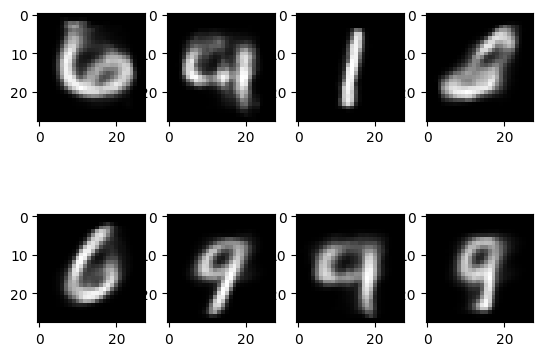

In [ ]:
import matplotlib.pyplot as plt
sample = sample.view(-1, 28, 28)
for i  in range(8):
  plt.subplot(2,4,i+1)
  plt.imshow(sample[i],cmap = 'gray')
plt.show()